In [1]:
import pyfolio as pf
import yfinance as yf

c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [2]:
data   = yf.Ticker('GS').history('max')

In [3]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1999-05-04 00:00:00-04:00,52.313512,53.173932,48.183498,48.441624,22320900,0.0,0.0
1999-05-05 00:00:00-04:00,48.097459,48.097459,45.602242,47.581207,7565700,0.0,0.0
1999-05-06 00:00:00-04:00,46.806834,47.753296,46.161519,46.763813,2905700,0.0,0.0
1999-05-07 00:00:00-04:00,46.763811,51.539140,45.946412,51.022888,4862300,0.0,0.0
1999-05-10 00:00:00-04:00,50.506629,50.592671,48.355580,48.656727,2589400,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-03 00:00:00-05:00,836.000000,868.340027,824.640015,862.580017,3782100,0.0,0.0
2026-03-04 00:00:00-05:00,869.840027,878.799988,860.000000,867.250000,2081700,0.0,0.0
2026-03-05 00:00:00-05:00,862.010010,866.520020,822.200012,835.460022,3093700,0.0,0.0


In [4]:
returns = data.Close.pct_change()

In [5]:
returns

Date
1999-05-04 00:00:00-04:00         NaN
1999-05-05 00:00:00-04:00   -0.017762
1999-05-06 00:00:00-04:00   -0.017179
1999-05-07 00:00:00-04:00    0.091076
1999-05-10 00:00:00-04:00   -0.046375
                               ...   
2026-03-03 00:00:00-05:00    0.001021
2026-03-04 00:00:00-05:00    0.005414
2026-03-05 00:00:00-05:00   -0.036656
2026-03-06 00:00:00-05:00   -0.016805
2026-03-09 00:00:00-04:00    0.012917
Name: Close, Length: 6753, dtype: float64

In [6]:
bench= yf.Ticker('SPY').history('max')

In [7]:
bench

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
1993-01-29 00:00:00-05:00,24.258635,24.258635,24.137946,24.241394,1003200,0.0,0.0,0.0
1993-02-01 00:00:00-05:00,24.258644,24.413816,24.258644,24.413816,480500,0.0,0.0,0.0
1993-02-02 00:00:00-05:00,24.396586,24.482793,24.344862,24.465551,201300,0.0,0.0,0.0
1993-02-03 00:00:00-05:00,24.500023,24.741403,24.482782,24.724161,529400,0.0,0.0,0.0
1993-02-04 00:00:00-05:00,24.810369,24.879334,24.534506,24.827610,531500,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-03-03 00:00:00-05:00,675.059998,682.609985,669.659973,680.330017,105003100,0.0,0.0,0.0
2026-03-04 00:00:00-05:00,681.630005,687.090027,679.619995,685.130005,79182200,0.0,0.0,0.0
2026-03-05 00:00:00-05:00,682.080017,685.530029,675.609985,681.309998,106606500,0.0,0.0,0.0


In [8]:
bench_returns = bench.Close.pct_change()

In [9]:
bench_returns

Date
1993-01-29 00:00:00-05:00         NaN
1993-02-01 00:00:00-05:00    0.007113
1993-02-02 00:00:00-05:00    0.002119
1993-02-03 00:00:00-05:00    0.010570
1993-02-04 00:00:00-05:00    0.004184
                               ...   
2026-03-03 00:00:00-05:00   -0.008814
2026-03-04 00:00:00-05:00    0.007055
2026-03-05 00:00:00-05:00   -0.005576
2026-03-06 00:00:00-05:00   -0.013107
2026-03-09 00:00:00-04:00    0.008760
Name: Close, Length: 8333, dtype: float64

In [10]:
returns = returns.dropna()
bench_returns = bench_returns.dropna()

In [11]:
returns, bench_returns = returns.align(bench_returns, join = 'inner')

In [12]:
returns

Date
1999-05-05 00:00:00-04:00   -0.017762
1999-05-06 00:00:00-04:00   -0.017179
1999-05-07 00:00:00-04:00    0.091076
1999-05-10 00:00:00-04:00   -0.046375
1999-05-11 00:00:00-04:00   -0.000884
                               ...   
2026-03-03 00:00:00-05:00    0.001021
2026-03-04 00:00:00-05:00    0.005414
2026-03-05 00:00:00-05:00   -0.036656
2026-03-06 00:00:00-05:00   -0.016805
2026-03-09 00:00:00-04:00    0.012917
Name: Close, Length: 6752, dtype: float64

In [13]:
bench_returns

Date
1999-05-05 00:00:00-04:00    0.007944
1999-05-06 00:00:00-04:00   -0.006142
1999-05-07 00:00:00-04:00    0.007580
1999-05-10 00:00:00-04:00   -0.004977
1999-05-11 00:00:00-04:00    0.010120
                               ...   
2026-03-03 00:00:00-05:00   -0.008814
2026-03-04 00:00:00-05:00    0.007055
2026-03-05 00:00:00-05:00   -0.005576
2026-03-06 00:00:00-05:00   -0.013107
2026-03-09 00:00:00-04:00    0.008760
Name: Close, Length: 6752, dtype: float64

c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.271%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '35.705%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and wi

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,78.84,2007-10-31,2008-11-20,2016-12-01,2372
1,54.59,2000-09-11,2002-10-09,2005-11-01,1342
2,48.75,2018-03-12,2020-03-23,2020-12-28,731
3,42.38,2000-03-24,2000-05-26,2000-08-28,112
4,32.84,2021-11-02,2022-06-17,2024-03-20,622


c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

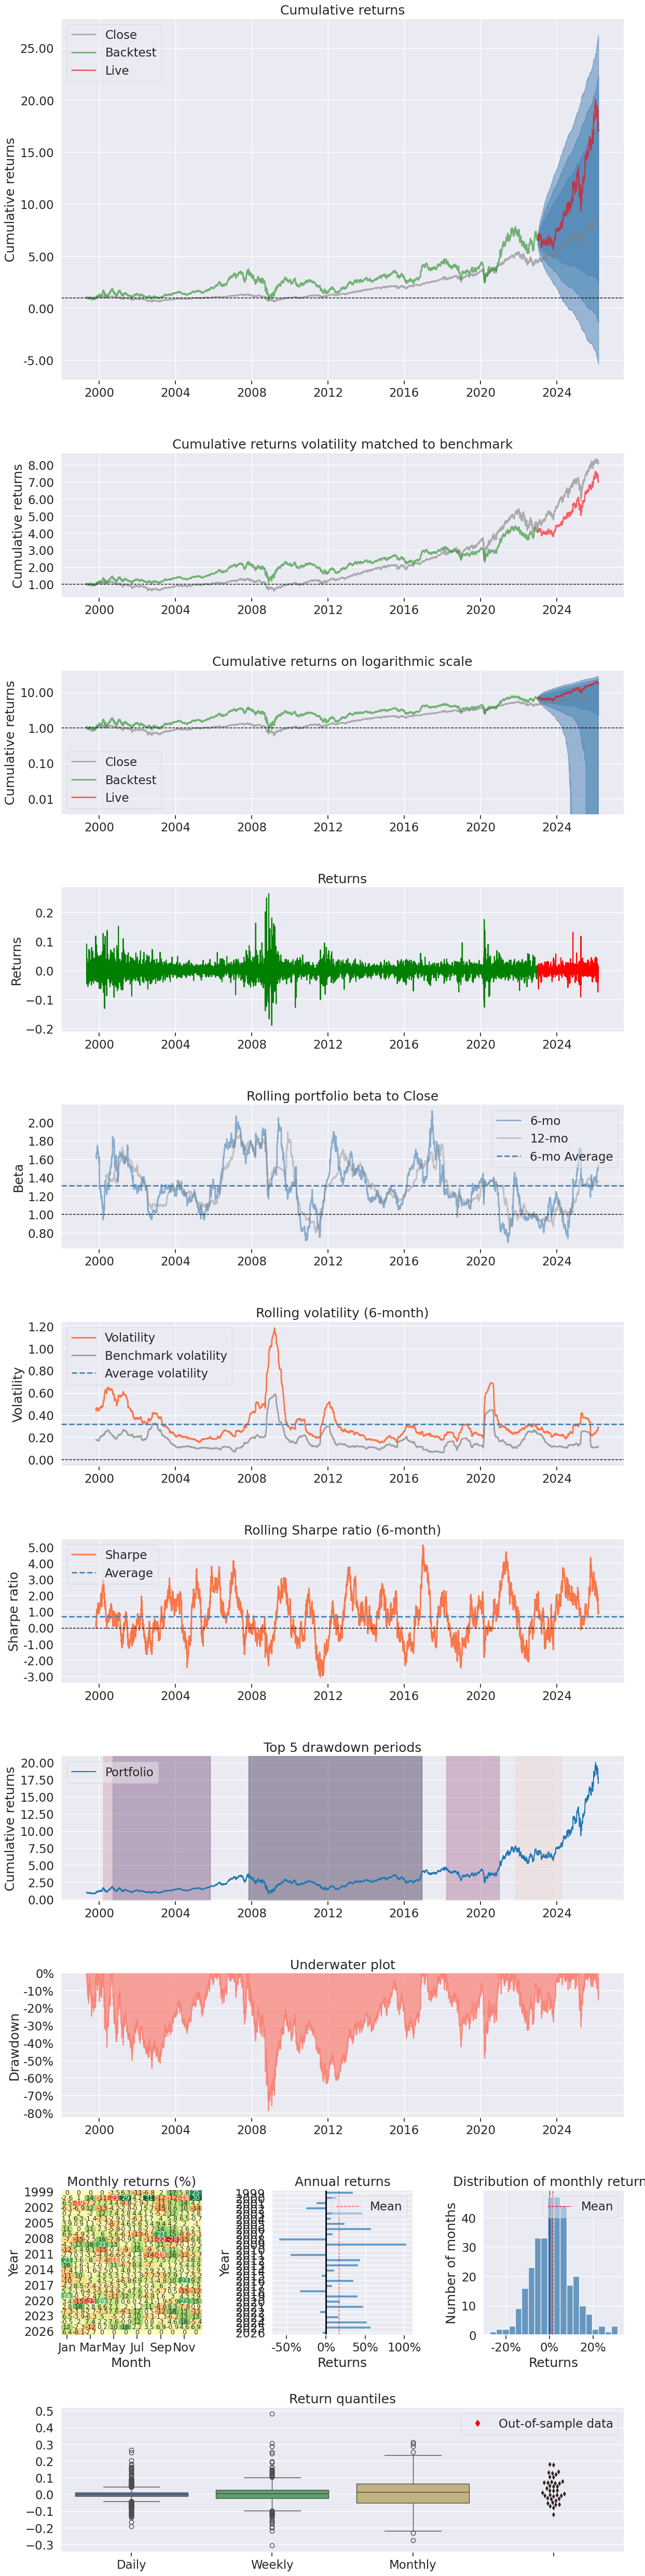

In [14]:
pf.create_returns_tear_sheet(returns, live_start_date='2023-01-01',benchmark_rets = bench_returns)

In [15]:
import pandas as pd
tickers = ['NVDA','GS','MSFT']
weights = pd.Series([0.4,0.4,0.2],index = tickers)

In [16]:
weights

NVDA    0.4
GS      0.4
MSFT    0.2
dtype: float64

In [17]:
prices = None
for t in tickers:
    h = yf.Ticker(t).history('max')[['Close']].rename(columns ={'Close':t})
    prices = h if prices is None else prices.join(h,how='inner' )

In [18]:
prices

,NVDA,GS,MSFT
Date,,,
1999-05-04 00:00:00-04:00,0.033188,48.441647,23.788189
1999-05-05 00:00:00-04:00,0.033904,47.581219,24.111952
1999-05-06 00:00:00-04:00,0.033247,46.763809,23.750093
1999-05-07 00:00:00-04:00,0.033426,51.022877,24.092926
1999-05-10 00:00:00-04:00,0.033426,48.656742,24.283363
...,...,...,...
2026-03-03 00:00:00-05:00,180.050003,862.580017,403.929993
2026-03-04 00:00:00-05:00,183.039993,867.250000,405.200012
2026-03-05 00:00:00-05:00,183.339996,835.460022,410.679993


In [19]:
asset_return = prices.pct_change().dropna()

In [22]:
returns = asset_return.mul(weights).sum(axis =1)

In [23]:
returns

Date
1999-05-05 00:00:00-04:00    0.004247
1999-05-06 00:00:00-04:00   -0.017618
1999-05-07 00:00:00-04:00    0.041468
1999-05-10 00:00:00-04:00   -0.016969
1999-05-11 00:00:00-04:00    0.021544
                               ...   
2026-03-03 00:00:00-05:00   -0.002218
2026-03-04 00:00:00-05:00    0.009437
2026-03-05 00:00:00-05:00   -0.011302
2026-03-06 00:00:00-05:00   -0.019603
2026-03-09 00:00:00-04:00    0.016252
Length: 6752, dtype: float64

In [24]:
bench_returns = bench.Close.pct_change()
returns, bench_returns = returns.align(bench_returns, join = 'inner')

In [25]:
returns

Date
1999-05-05 00:00:00-04:00    0.004247
1999-05-06 00:00:00-04:00   -0.017618
1999-05-07 00:00:00-04:00    0.041468
1999-05-10 00:00:00-04:00   -0.016969
1999-05-11 00:00:00-04:00    0.021544
                               ...   
2026-03-03 00:00:00-05:00   -0.002218
2026-03-04 00:00:00-05:00    0.009437
2026-03-05 00:00:00-05:00   -0.011302
2026-03-06 00:00:00-05:00   -0.019603
2026-03-09 00:00:00-04:00    0.016252
Length: 6752, dtype: float64

c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '21.748%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '65.867%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and w

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,75.04,2007-10-31,2008-11-20,2014-08-26,1780
1,67.13,2002-01-04,2002-10-09,2005-11-02,999
2,45.06,2000-09-01,2000-12-21,2001-04-20,166
3,44.02,2021-11-24,2022-10-14,2023-05-25,392
4,39.66,2018-09-04,2018-12-24,2019-12-16,335


c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
c:\Users\akhil\OneDrive\Desktop\STOCK-PORTFOLIO-ANALYSIS\stock\.venv\Lib\site-packages\pyfolio\plotting.py:1391: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.swarmplot(
c:\Users\akhil\OneDrive\Desktop

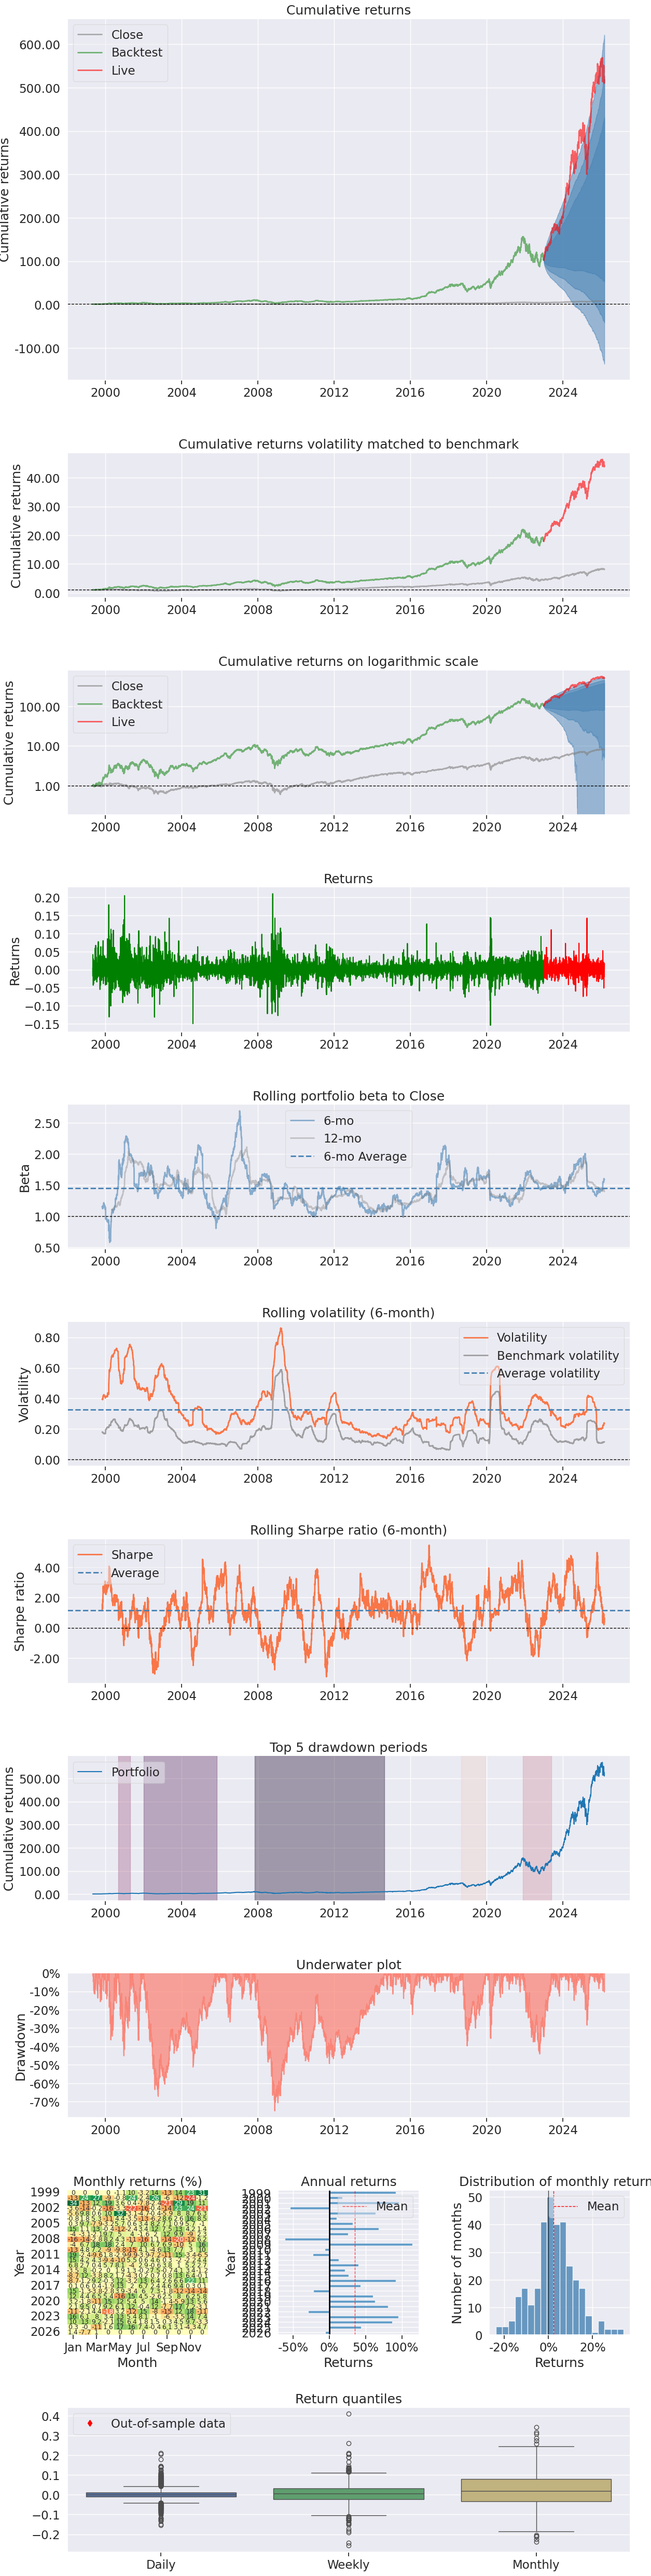

In [26]:
pf.create_returns_tear_sheet(returns, live_start_date='2023-01-01',benchmark_rets = bench_returns)